# University Machine Learning Final Project: Water Consumption Prediction
### Objective: Predict November Water Consumption using Regression Models
**Author:** Student
**Course:** Machine Learning Final Project

---

## 1. Data Understanding

In this initial phase, we load the raw water consumption dataset, inspect its structure, dimensions, data types, and check for any missing values or duplicate records. This step is critical for diagnosing data quality issues before preprocessing.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
import json

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12


### Load and Inspect Dataset

In [3]:
# Load dataset
data_path = 'dataset/Data_Set_Statistics.csv'
df = pd.read_csv(data_path)

# Display shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display data types
print("--- Data Types ---")
print(df.dtypes)
print()


Dataset Shape: 11047 rows, 7 columns

--- Data Types ---
#                float64
Customer Name    float64
Branch            object
Zone              object
September        float64
October          float64
November         float64
dtype: object



### Display First 10 Rows

In [4]:
df.head(10)


,#,Customer Name,Branch,Zone,September,October,November
0,158.0,NaN,Dayniile,Gubta 1,20.0,15.0,13.0
1,319.0,NaN,Dayniile,Gubta 1,11.0,12.0,15.0
2,740.0,NaN,Dayniile,Gubta 1,2.0,2.0,1.0
3,741.0,NaN,Dayniile,Gubta 1,6.0,5.0,6.0
4,742.0,NaN,Dayniile,Gubta 1,3.0,3.0,3.0
5,743.0,NaN,Dayniile,Gubta 1,2.0,3.0,3.0
6,744.0,NaN,Dayniile,Gubta 1,7.0,7.0,8.0
7,745.0,NaN,Dayniile,Gubta 1,19.0,15.0,16.0
8,746.0,NaN,Dayniile,Gubta 1,6.0,7.0,7.0
9,747.0,NaN,Dayniile,Gubta 1,5.0,5.0,4.0


### Summary Statistics

In [5]:
df.describe(include='all')


,#,Customer Name,Branch,Zone,September,October,November
count,11044.000000,0.0,11044,11044,11044.000000,11044.000000,11044.000000
unique,NaN,NaN,7,21,NaN,NaN,NaN
top,NaN,NaN,Dayniile,Wardheere,NaN,NaN,NaN
freq,NaN,NaN,3138,761,NaN,NaN,NaN
mean,5259.831854,NaN,NaN,NaN,10.959326,11.274221,11.841015
std,3593.404371,NaN,NaN,NaN,82.108731,86.664783,89.641848
min,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,1590.750000,NaN,NaN,NaN,3.000000,3.000000,3.000000
50%,5182.500000,NaN,NaN,NaN,6.000000,6.000000,7.000000
75%,8119.000000,NaN,NaN,NaN,11.000000,11.000000,12.000000


### Check Duplicate Records and Missing Values

In [6]:
duplicates = df.duplicated().sum()
missing_values = df.isnull().sum()

print(f"Number of Duplicate Records: {duplicates}")
print("\n--- Missing Values per Column ---")
print(missing_values)


Number of Duplicate Records: 2

--- Missing Values per Column ---
#                    3
Customer Name    11047
Branch               3
Zone                 3
September            3
October              3
November             3
dtype: int64


## 2. Data Cleaning

### Decisions and Explanations:
1. **Unnecessary Columns Removal:** `#` (Record ID) and `Customer Name` are unique identifiers with no predictive capability. Retaining them would cause overfitting or noise. We will remove them.
2. **Handling Missing Values:** If there are missing values in numerical input features (`September`, `October`) or target (`November`), we will impute them using median values because median is robust to outliers. If categorical fields (`Branch`, `Zone`) have missing values, we will fill them with the mode (most frequent value).
3. **Handling Duplicate Records:** Duplicate rows represent redundant information and will be removed to ensure evaluation metrics are unbiased and realistic.

In [7]:
# 1. Drop unnecessary columns
cols_to_drop = ['#', 'Customer Name']
df_cleaned = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')
print(f"Columns after dropping ID/Name: {df_cleaned.columns.tolist()}")

# 2. Handle missing values
for col in ['September', 'October', 'November']:
    if col in df_cleaned.columns:
        # Convert to numeric if not already
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

for col in ['Branch', 'Zone']:
    if col in df_cleaned.columns:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_val)

# 3. Handle duplicates
before = df.shape
df = df.drop_duplicates()
after = df.shape
print("remove duplicate: ", before, "->", after)
# before_dedup = df_cleaned.shape[0]
# df_cleaned.drop_duplicates(inplace=True)
# after_dedup = df_cleaned.shape[0]
# print(f"Removed {before_dedup - after_dedup} duplicate records. Remaining: {after_dedup} rows.")


Columns after dropping ID/Name: ['Branch', 'Zone', 'September', 'October', 'November']
remove duplicate:  (11047, 7) -> (11045, 7)


## 3. Exploratory Data Analysis (EDA)

We perform graphical EDA to understand feature distributions, identify outliers, and evaluate dependencies.

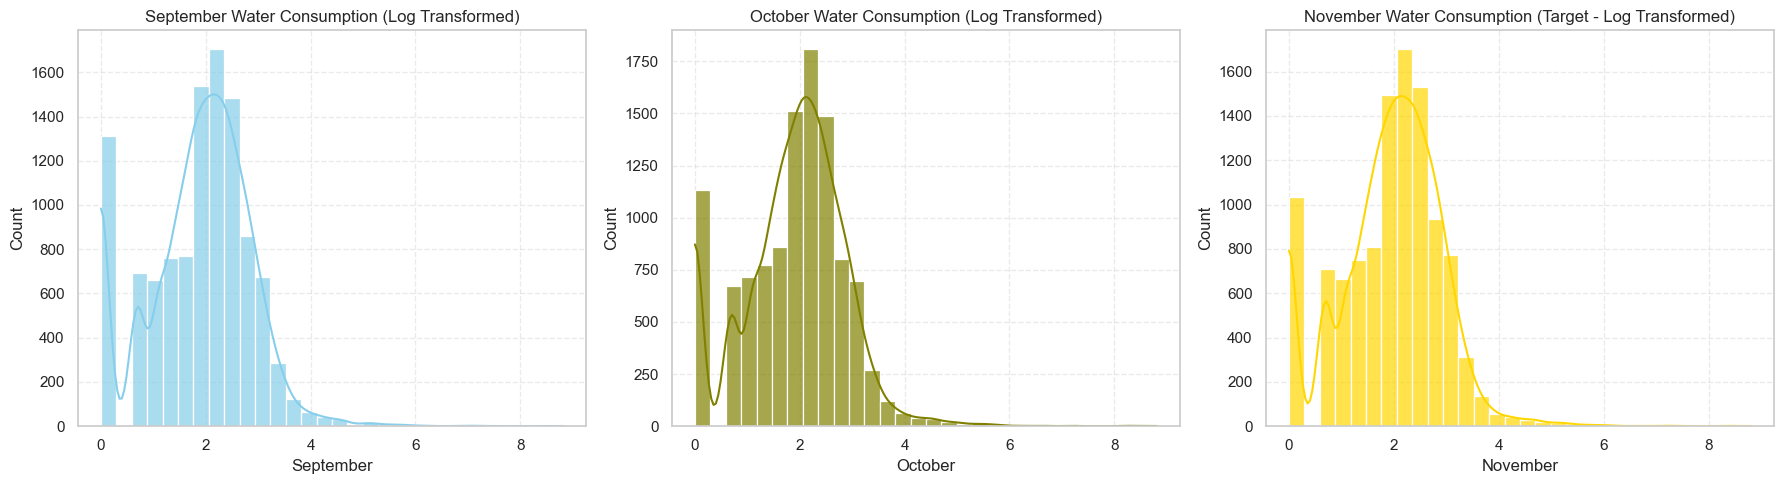

In [35]:
# Log transformation (use log1p to safely handle zeros)
df_log = df_cleaned.copy()

df_log['September'] = np.log1p(df_log['September'])
df_log['October'] = np.log1p(df_log['October'])
df_log['November'] = np.log1p(df_log['November'])

# Plot
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# September
sns.histplot(
    df_log['September'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='white',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('September Water Consumption (Log Transformed)')
axes[0].set_xlabel('September')
axes[0].set_ylabel('Count')
axes[0].grid(True, linestyle='--', alpha=0.4)

# October
sns.histplot(
    df_log['October'],
    bins=30,
    kde=True,
    color='olive',
    edgecolor='white',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('October Water Consumption (Log Transformed)')
axes[1].set_xlabel('October')
axes[1].set_ylabel('Count')
axes[1].grid(True, linestyle='--', alpha=0.4)

# November
sns.histplot(
    df_log['November'],
    bins=30,
    kde=True,
    color='gold',
    edgecolor='white',
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title('November Water Consumption (Target - Log Transformed)')
axes[2].set_xlabel('November')
axes[2].set_ylabel('Count')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Boxplots for Outlier Detection

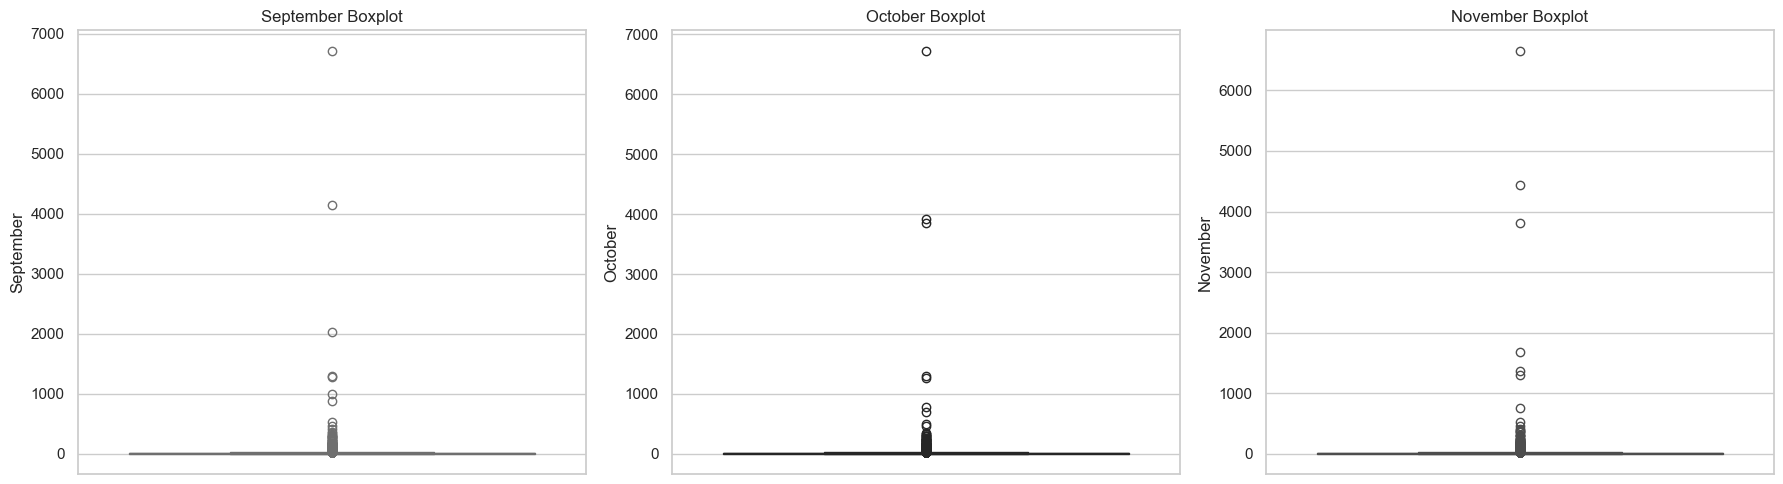

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df_cleaned['September'], ax=axes[0], color='skyblue')
axes[0].set_title('September Boxplot')

sns.boxplot(y=df_cleaned['October'], ax=axes[1], color='olive')
axes[1].set_title('October Boxplot')

sns.boxplot(y=df_cleaned['November'], ax=axes[2], color='gold')
axes[2].set_title('November Boxplot')
plt.tight_layout()
plt.show()


### Feature Relationship Analysis (Scatter plots vs Target)

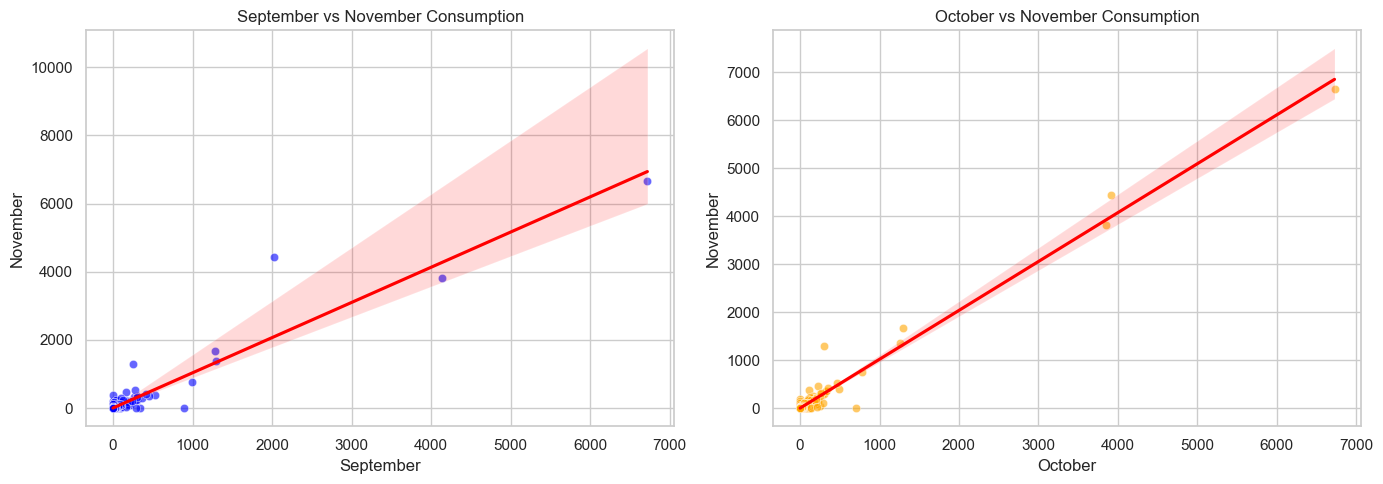

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# September vs November
sns.scatterplot(data=df_cleaned, x='September', y='November',
                ax=axes[0], alpha=0.6, color='blue')

sns.regplot(data=df_cleaned, x='September', y='November',
            ax=axes[0], scatter=False, color='red')

axes[0].set_title('September vs November Consumption')

# October vs November
sns.scatterplot(data=df_cleaned, x='October', y='November',
                ax=axes[1], alpha=0.6, color='orange')

sns.regplot(data=df_cleaned, x='October', y='November',
            ax=axes[1], scatter=False, color='red')

axes[1].set_title('October vs November Consumption')

plt.tight_layout()
plt.show()

### Correlation Heatmap (Numeric features)

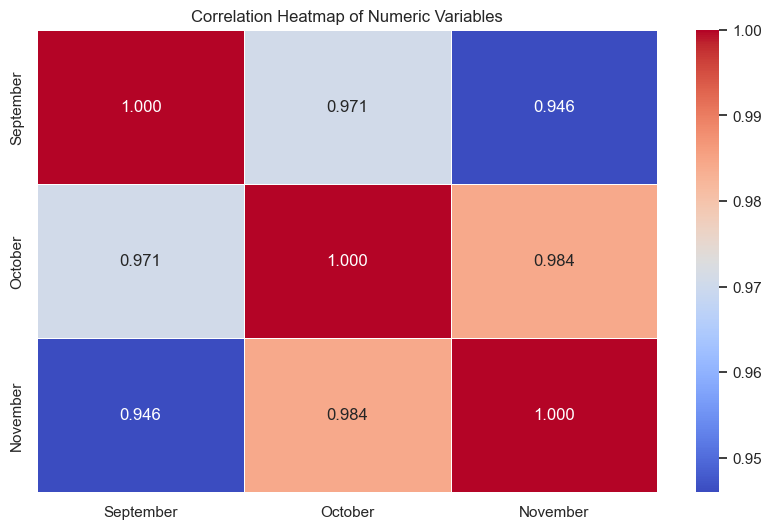

In [11]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


## 4. Feature Engineering

We engineer new features to extract more predictive signals from the historical consumption trajectory, incorporating seasonal trends, household size, and customer type estimations:
1. **Average Consumption (`Average_Consumption`):** Mean of September and October, representing the baseline usage level.
2. **Consumption Difference (`Consumption_Difference`):** October - September, capturing short-term direction trends.
3. **Consumption Growth Rate (`Consumption_Growth_Rate`):** (October - September) / (September + 0.1), capturing proportional rate of change.


In [12]:
# Engineering features
df_cleaned['Average_Consumption'] = (df_cleaned['September'] + df_cleaned['October']) / 2.0
df_cleaned['Consumption_Difference'] = df_cleaned['October'] - df_cleaned['September']
df_cleaned['Consumption_Growth_Rate'] = (df_cleaned['October'] - df_cleaned['September']) / (df_cleaned['September'] + 0.1)

df_cleaned[['September', 'October', 'Average_Consumption', 'Consumption_Difference', 
            'Consumption_Growth_Rate']].head(10)


,September,October,Average_Consumption,Consumption_Difference,Consumption_Growth_Rate
0,20.0,15.0,17.5,-5.0,-0.248756
1,11.0,12.0,11.5,1.0,0.090090
2,2.0,2.0,2.0,0.0,0.000000
3,6.0,5.0,5.5,-1.0,-0.163934
4,3.0,3.0,3.0,0.0,0.000000
5,2.0,3.0,2.5,1.0,0.476190
6,7.0,7.0,7.0,0.0,0.000000
7,19.0,15.0,17.0,-4.0,-0.209424
8,6.0,7.0,6.5,1.0,0.163934
9,5.0,5.0,5.0,0.0,0.000000


## 5. Encoding

We encode categorical features (`Branch`, `Zone`) using `OneHotEncoder` since tree-based and linear models require numeric representations. This produces sparse binary indicators for each unique location category.

In [13]:
# Categorical Columns to encode
cat_cols = ['Branch', 'Zone']

# Initialize OneHotEncoder with handle_unknown='ignore' to be robust to new unseen test categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(df_cleaned[cat_cols])
ohe_col_names = ohe.get_feature_names_out(cat_cols)

# Create DataFrame of encoded features
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe_col_names, index=df_cleaned.index)

# Concat with original numerical columns
df_model = pd.concat([df_cleaned.drop(columns=cat_cols), df_ohe], axis=1)
print(f"Shape after One-Hot Encoding: {df_model.shape}")


Shape after One-Hot Encoding: (11047, 34)


## 6. Feature Selection

Let's evaluate correlations of features with the target `November` and examine feature importances from a baseline Random Forest Regressor to confirm the predictive utility of the engineered features.

In [14]:
# Correlation with target column
corrs_with_target = df_model.corr()['November'].sort_values(ascending=False)
print("--- Top 10 Features Correlated with November Water Consumption ---")
print(corrs_with_target.head(10))

# Fit a temporary Random Forest to get feature importances
X_temp = df_model.drop(columns=['November'])
y_temp = df_model['November']
rf_temp = RandomForestRegressor(n_estimators=50, random_state=42)
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns).sort_values(ascending=False)
print("\n--- Top 10 Feature Importances via Random Forest ---")
print(importances.head(10))


--- Top 10 Features Correlated with November Water Consumption ---
November                  1.000000
October                   0.984281
Average_Consumption       0.972846
September                 0.946051
Consumption_Difference    0.363961
Zone_Maajo                0.047067
Zone_H.Wadaag 1           0.045212
Branch_Bakaaro            0.043362
Zone_W.Nabada 1           0.036285
Branch_Waaberi            0.032357
Name: November, dtype: float64

--- Top 10 Feature Importances via Random Forest ---
October                    0.361342
Average_Consumption        0.310366
September                  0.286794
Consumption_Difference     0.013863
Consumption_Growth_Rate    0.012180
Zone_W.Nabada 1            0.005322
Branch_Dayniile            0.003223
Branch_Waaberi             0.002860
Zone_H.Wadaag 1            0.001486
Zone_Yaaqshiid             0.000472
dtype: float64


Based on the high correlation and feature importance metrics, we select all features including engineered ones and spatial category encodings to provide maximum predictive coverage.

## 7. Data Splitting

We split our data into an 80% training set and 20% test set, using a fixed random seed of `42` to ensure replicability.

In [15]:
X = df_model.drop(columns=['November'])
y = df_model['November']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Set: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Set: X={X_test.shape}, y={y_test.shape}")


Training Set: X=(8837, 33), y=(8837,)
Testing Set: X=(2210, 33), y=(2210,)


## 8. Feature Scaling

We apply `StandardScaler` to the continuous numerical features to normalize their scale. Tree models do not require scaling, but distance-based and linear models (like Linear Regression) require feature normalization to avoid coefficient scaling biases.

In [16]:
num_features = ['September', 'October', 'Average_Consumption', 'Consumption_Difference', 'Consumption_Growth_Rate']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print("Continuous numerical features scaled successfully.")


Continuous numerical features scaled successfully.


## 9. Train 5 Regression Models with Default Parameters

We train all five requested regression algorithms using their default model hyperparameters. A fixed `random_state` is supplied where supported so results are reproducible, but the model behavior is otherwise left at each estimator's defaults.

1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**
5. **XGBoost Regressor**


In [17]:
# Initialize all five models with default model hyperparameters.
# random_state/n_jobs are set only for reproducibility and runtime control.
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=1, objective="reg:squarederror")
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained {name} with default parameters")


Trained Linear Regression with default parameters
Trained Decision Tree with default parameters
Trained Random Forest with default parameters
Trained Gradient Boosting with default parameters
Trained XGBoost with default parameters


## 9.1 Naive Baseline Model

Before evaluating our trained ML models, we establish a **naive baseline** to put their performance into perspective.

The naive baseline uses the simplest possible prediction rule:

```
November Prediction = October Consumption
```

This baseline assumes that next month's consumption will be exactly the same as the current month.
Any useful ML model **must beat** this baseline to justify its added complexity.
We include it in the evaluation table alongside the 5 trained models for direct comparison.

In [18]:
# --- Naive Baseline: Predict November = October ---
# Use the raw (unscaled) October values from the test set
baseline_preds = X_test['October'].values

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_preds)

print("=== Naive Baseline (Last Month) ===")
print(f"  MAE:  {baseline_mae:.4f}")
print(f"  RMSE: {baseline_rmse:.4f}")
print(f"  R²:   {baseline_r2:.4f}")


=== Naive Baseline (Last Month) ===
  MAE:  3.0923
  RMSE: 10.6937
  R²:   0.9855


## 10. Model Evaluation

Each model is evaluated on the held-out test set using **MAE**, **RMSE**, and **R²**. We also run **5-fold cross-validation** on the training data so model selection is not based on one split alone.


In [19]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R² Score": r2_score(y_true, y_pred)
    }

# Add Naive Baseline first for context. It is not part of the five-model selection pool.
evaluation_results = [{
    "Model": "Naive Baseline (Last Month)",
    **regression_metrics(y_test, baseline_preds)
}]

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    evaluation_results.append({
        "Model": name,
        **regression_metrics(y_test, preds)
    })

df_eval = pd.DataFrame(evaluation_results)
df_eval


,Model,MAE,RMSE,R² Score
0,Naive Baseline (Last Month),3.092308,10.693667,0.985456
1,Linear Regression,3.340233,11.413981,0.983431
2,Decision Tree,4.651159,22.022320,0.938318
3,Random Forest,3.724283,15.901598,0.967840
4,Gradient Boosting,4.048982,30.997836,0.877794
5,XGBoost,3.737260,19.103314,0.953586


In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": rmse_scorer,
    "R2": "r2"
}

cv_results = []

for name, model in models.items():
    pipe = make_pipeline(StandardScaler(), clone(model))
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_results.append({
        "Model": name,
        "CV MAE Mean": -scores["test_MAE"].mean(),
        "CV MAE Std": scores["test_MAE"].std(),
        "CV RMSE Mean": -scores["test_RMSE"].mean(),
        "CV RMSE Std": scores["test_RMSE"].std(),
        "CV R² Mean": scores["test_R2"].mean(),
        "CV R² Std": scores["test_R2"].std(),
        "CV R² Fold Scores": [round(s, 4) for s in scores["test_R2"]]
    })
    print(
        f"{name:20s} | CV MAE: {-scores['test_MAE'].mean():.4f} | "
        f"CV RMSE: {-scores['test_RMSE'].mean():.4f} | "
        f"CV R²: {scores['test_R2'].mean():.4f} ± {scores['test_R2'].std():.4f}"
    )

df_cv = pd.DataFrame(cv_results)
print("\n--- 5-Fold Cross-Validation Results ---")
df_cv[["Model", "CV MAE Mean", "CV RMSE Mean", "CV R² Mean", "CV R² Std"]]


Linear Regression    | CV MAE: 3.4130 | CV RMSE: 13.8395 | CV R²: 0.8379 ± 0.1917
Decision Tree        | CV MAE: 4.6364 | CV RMSE: 30.6955 | CV R²: 0.7708 ± 0.1515
Random Forest        | CV MAE: 4.1177 | CV RMSE: 33.7319 | CV R²: 0.7175 ± 0.2013
Gradient Boosting    | CV MAE: 3.9915 | CV RMSE: 32.1091 | CV R²: 0.7421 ± 0.1698
XGBoost              | CV MAE: 3.9968 | CV RMSE: 31.0982 | CV R²: 0.7146 ± 0.2267

--- 5-Fold Cross-Validation Results ---


,Model,CV MAE Mean,CV RMSE Mean,CV R² Mean,CV R² Std
0,Linear Regression,3.413036,13.839525,0.837890,0.191704
1,Decision Tree,4.636378,30.695537,0.770810,0.151450
2,Random Forest,4.117720,33.731877,0.717467,0.201333
3,Gradient Boosting,3.991490,32.109135,0.742056,0.169775
4,XGBoost,3.996792,31.098158,0.714579,0.226654


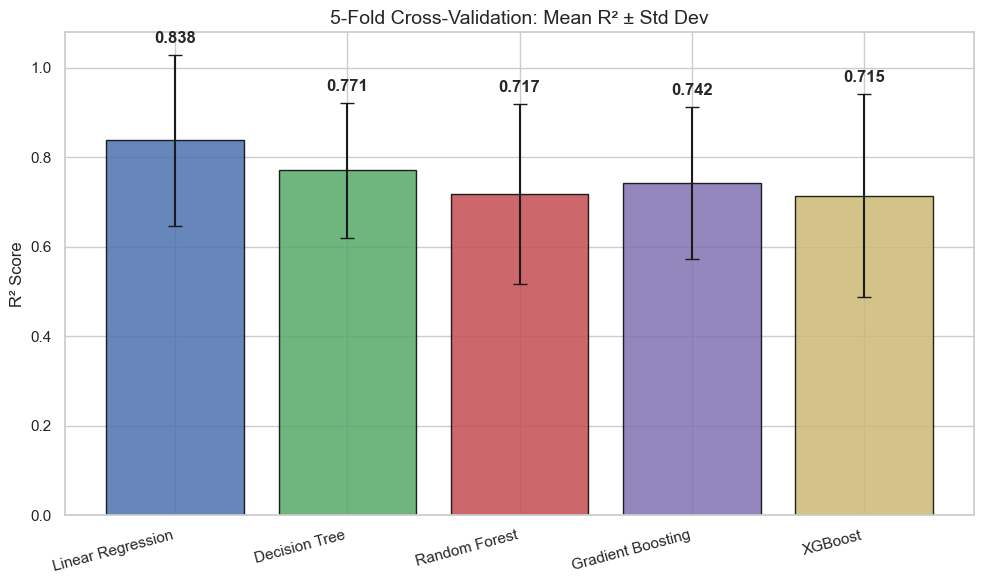

In [21]:
# Visualize cross-validation R² results
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(
    df_cv['Model'],
    df_cv['CV R² Mean'],
    yerr=df_cv['CV R² Std'],
    capsize=5,
    color=colors,
    edgecolor='black',
    alpha=0.85
)
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation: Mean R² ± Std Dev', fontsize=14)
ax.set_ylim(0, max(1.05, (df_cv['CV R² Mean'] + df_cv['CV R² Std']).max() + 0.05))
plt.xticks(rotation=15, ha='right')

for bar, mean_val, std_val in zip(bars, df_cv['CV R² Mean'], df_cv['CV R² Std']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std_val + 0.02,
        f'{mean_val:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


## 11. Model Comparison & Ranking

We rank the models from best to worst based on cross-validated R² Mean score (descending) and RMSE Mean (ascending).

In [22]:
# Rank the five trained ML models using both held-out test metrics and CV metrics.
df_model_eval = df_eval[df_eval["Model"].isin(models.keys())].merge(
    df_cv[["Model", "CV MAE Mean", "CV RMSE Mean", "CV R² Mean", "CV R² Std"]],
    on="Model",
    how="left"
)

ranked = df_model_eval.copy()
ranked["Test R² Rank"] = ranked["R² Score"].rank(ascending=False, method="min")
ranked["Test RMSE Rank"] = ranked["RMSE"].rank(ascending=True, method="min")
ranked["CV R² Rank"] = ranked["CV R² Mean"].rank(ascending=False, method="min")
ranked["CV RMSE Rank"] = ranked["CV RMSE Mean"].rank(ascending=True, method="min")
ranked["Composite Rank Score"] = ranked[["Test R² Rank", "Test RMSE Rank", "CV R² Rank", "CV RMSE Rank"]].sum(axis=1)

df_ranked = ranked.sort_values(
    by=["Composite Rank Score", "R² Score", "CV R² Mean", "RMSE"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

print("--- Model Rankings (Best to Worst) ---")
df_ranked[["Model", "MAE", "RMSE", "R² Score", "CV MAE Mean", "CV RMSE Mean", "CV R² Mean", "Composite Rank Score"]]


--- Model Rankings (Best to Worst) ---


,Model,MAE,RMSE,R² Score,CV MAE Mean,CV RMSE Mean,CV R² Mean,Composite Rank Score
0,Linear Regression,3.340233,11.413981,0.983431,3.413036,13.839525,0.837890,4.0
1,Decision Tree,4.651159,22.022320,0.938318,4.636378,30.695537,0.770810,12.0
2,Random Forest,3.724283,15.901598,0.967840,4.117720,33.731877,0.717467,13.0
3,XGBoost,3.737260,19.103314,0.953586,3.996792,31.098158,0.714579,14.0
4,Gradient Boosting,4.048982,30.997836,0.877794,3.991490,32.109135,0.742056,17.0


## 12. Hyperparameter Tuning via GridSearchCV

We select the top one to three models from the combined test/CV ranking, then tune only those selected models with `GridSearchCV`. The tuned models are compared directly against their untuned versions.


In [23]:
top_n = min(3, len(df_ranked))
selected_model_names = df_ranked.head(top_n)["Model"].tolist()
print(f"Selected models for tuning: {selected_model_names}")

param_grids = {
    "Linear Regression": {
        "fit_intercept": [True, False]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2]
    },
    "Random Forest": {
        "n_estimators": [50],
        "max_depth": [None, 10],
        "min_samples_leaf": [1, 2]
    },
    "Gradient Boosting": {
        "n_estimators": [100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4]
    },
    "XGBoost": {
        "n_estimators": [100],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    }
}

def clone_for_search(model):
    estimator = clone(model)
    if "n_jobs" in estimator.get_params():
        estimator.set_params(n_jobs=1)
    return estimator

tuned_models = {}
tuning_results = []

for name in selected_model_names:
    grid = GridSearchCV(
        estimator=clone_for_search(models[name]),
        param_grid=param_grids[name],
        cv=cv,
        scoring="r2",
        n_jobs=1,
        refit=True
    )
    grid.fit(X_train_scaled, y_train)
    tuned_models[name] = grid.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best GridSearch CV R²": grid.best_score_
    })
    print(f"Best {name} params: {grid.best_params_}")
    print(f"Best {name} GridSearch CV R²: {grid.best_score_:.4f}\n")

df_tuning = pd.DataFrame(tuning_results)
df_tuning


Selected models for tuning: ['Linear Regression', 'Decision Tree', 'Random Forest']
Best Linear Regression params: {'fit_intercept': True}
Best Linear Regression GridSearch CV R²: 0.7169

Best Decision Tree params: {'max_depth': 5, 'min_samples_leaf': 2}
Best Decision Tree GridSearch CV R²: 0.1954

Best Random Forest params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}
Best Random Forest GridSearch CV R²: 0.4540



,Model,Best Params,Best GridSearch CV R²
0,Linear Regression,{'fit_intercept': True},0.716865
1,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 2}",0.195385
2,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.453983


In [24]:
# Compare each tuned model with its untuned version using both test-set metrics and 5-fold CV.
comparison_rows = []

def evaluate_model_version(model_name, version, model):
    preds = model.predict(X_test_scaled)
    test_metrics = regression_metrics(y_test, preds)
    pipe = make_pipeline(StandardScaler(), clone(model))
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
    return {
        "Model": model_name,
        "Version": version,
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "R² Score": test_metrics["R² Score"],
        "CV MAE Mean": -scores["test_MAE"].mean(),
        "CV RMSE Mean": -scores["test_RMSE"].mean(),
        "CV R² Mean": scores["test_R2"].mean(),
        "CV R² Std": scores["test_R2"].std()
    }

for name in selected_model_names:
    comparison_rows.append(evaluate_model_version(name, "Untuned", models[name]))
    comparison_rows.append(evaluate_model_version(name, "Tuned", tuned_models[name]))

df_tuned_comparison = pd.DataFrame(comparison_rows)
df_tuned_comparison["R² Change vs Untuned"] = df_tuned_comparison.groupby("Model")["R² Score"].diff()
df_tuned_comparison["RMSE Change vs Untuned"] = df_tuned_comparison.groupby("Model")["RMSE"].diff()

df_tuned_comparison.sort_values(
    by=["Model", "Version"],
    ascending=[True, False]
).reset_index(drop=True)


,Model,Version,MAE,RMSE,R² Score,CV MAE Mean,CV RMSE Mean,CV R² Mean,CV R² Std,R² Change vs Untuned,RMSE Change vs Untuned
0,Decision Tree,Untuned,4.651159,22.022320,0.938318,4.636378,30.695537,0.770810,0.151450,NaN,NaN
1,Decision Tree,Tuned,4.900609,39.160048,0.804963,4.655157,32.627083,0.742619,0.155737,-0.133355,17.137728
2,Linear Regression,Untuned,3.340233,11.413981,0.983431,3.413036,13.839525,0.837890,0.191704,NaN,NaN
3,Linear Regression,Tuned,3.340233,11.413981,0.983431,3.413036,13.839525,0.837890,0.191704,0.000000,0.000000
4,Random Forest,Untuned,3.724283,15.901598,0.967840,4.117720,33.731877,0.717467,0.201333,NaN,NaN
5,Random Forest,Tuned,3.575982,20.377059,0.947190,3.852207,32.439316,0.695304,0.263683,-0.020650,4.475462


## 13. Final Model Selection

The final model is chosen from all untuned models plus the tuned candidates. Selection uses a composite ranking that rewards stronger held-out test performance and stronger 5-fold cross-validation performance.


In [25]:
selection_rows = []
model_objects_for_selection = {}
model_predictions_for_selection = {}

for name, model in models.items():
    entry = evaluate_model_version(name, "Untuned", model)
    display_name = name
    selection_rows.append({"Display Model": display_name, **entry})
    model_objects_for_selection[display_name] = model
    model_predictions_for_selection[display_name] = model.predict(X_test_scaled)

for name, model in tuned_models.items():
    entry = evaluate_model_version(name, "Tuned", model)
    display_name = f"Tuned {name}"
    selection_rows.append({"Display Model": display_name, **entry})
    model_objects_for_selection[display_name] = model
    model_predictions_for_selection[display_name] = model.predict(X_test_scaled)

df_final_selection = pd.DataFrame(selection_rows)
df_final_selection["Test R² Rank"] = df_final_selection["R² Score"].rank(ascending=False, method="min")
df_final_selection["Test RMSE Rank"] = df_final_selection["RMSE"].rank(ascending=True, method="min")
df_final_selection["CV R² Rank"] = df_final_selection["CV R² Mean"].rank(ascending=False, method="min")
df_final_selection["CV RMSE Rank"] = df_final_selection["CV RMSE Mean"].rank(ascending=True, method="min")
df_final_selection["Composite Rank Score"] = df_final_selection[["Test R² Rank", "Test RMSE Rank", "CV R² Rank", "CV RMSE Rank"]].sum(axis=1)

df_final_selection = df_final_selection.sort_values(
    by=["Composite Rank Score", "R² Score", "CV R² Mean", "RMSE"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

final_model_name = df_final_selection.loc[0, "Display Model"]
final_model = model_objects_for_selection[final_model_name]
final_preds = model_predictions_for_selection[final_model_name]

print("--- Final Model Selection Table ---")
display(df_final_selection[["Display Model", "Version", "MAE", "RMSE", "R² Score", "CV MAE Mean", "CV RMSE Mean", "CV R² Mean", "Composite Rank Score"]])

print(
    f"\nSelected Final Model: {final_model_name} | "
    f"Test R²: {df_final_selection.loc[0, 'R² Score']:.4f}, "
    f"Test RMSE: {df_final_selection.loc[0, 'RMSE']:.4f}, "
    f"CV R²: {df_final_selection.loc[0, 'CV R² Mean']:.4f}"
)


--- Final Model Selection Table ---


,Display Model,Version,MAE,RMSE,R² Score,CV MAE Mean,CV RMSE Mean,CV R² Mean,Composite Rank Score
0,Linear Regression,Untuned,3.340233,11.413981,0.983431,3.413036,13.839525,0.837890,4.0
1,Tuned Linear Regression,Tuned,3.340233,11.413981,0.983431,3.413036,13.839525,0.837890,4.0
2,Decision Tree,Untuned,4.651159,22.022320,0.938318,4.636378,30.695537,0.770810,18.0
3,XGBoost,Untuned,3.737260,19.103314,0.953586,3.996792,31.098158,0.714579,19.0
4,Random Forest,Untuned,3.724283,15.901598,0.967840,4.117720,33.731877,0.717467,20.0
5,Tuned Random Forest,Tuned,3.575982,20.377059,0.947190,3.852207,32.439316,0.695304,24.0
6,Gradient Boosting,Untuned,4.048982,30.997836,0.877794,3.991490,32.109135,0.742056,24.0
7,Tuned Decision Tree,Tuned,4.900609,39.160048,0.804963,4.655157,32.627083,0.742619,27.0



Selected Final Model: Linear Regression | Test R²: 0.9834, Test RMSE: 11.4140, CV R²: 0.8379


## 14. Train Predictions: Actual vs Predicted (First 20 Rows)

In [26]:
train_preds = final_model.predict(X_train_scaled)
df_train_res = pd.DataFrame({
    'Actual November': y_train.values,
    'Predicted November': train_preds
})
df_train_res.head(20)


,Actual November,Predicted November
0,17.0,5.605705
1,5.0,5.872288
2,7.0,6.680342
3,0.0,0.202114
4,2.0,2.976922
5,8.0,9.268231
6,3.0,3.125639
7,13.0,14.267098
8,26.0,10.873972
9,8.0,6.136780


## 15. Test Predictions: Actual vs Predicted (First 20 Rows)

In [27]:
df_test_res = pd.DataFrame({
    'Actual November': y_test.values,
    'Predicted November': final_preds
})
df_test_res.head(20)


,Actual November,Predicted November
0,4.0,7.961050
1,8.0,7.194896
2,23.0,17.730270
3,19.0,2.149930
4,12.0,7.392544
5,8.0,8.855928
6,12.0,8.952486
7,8.0,8.731163
8,17.0,11.898057
9,37.0,34.956460


## 16. Single Prediction Sanity Check

We run a detailed sanity check on a single sample (index = 1) to inspect specific feature values, target outcome, and prediction error.

In [28]:
# ==========================================================
# SINGLE PREDICTION SANITY CHECK - ALL AVAILABLE MODELS
# ==========================================================

sample_idx = min(1056, len(X_test_scaled) - 1)

sample_row = X_test_scaled.iloc[[sample_idx]]
actual_val = y_test.iloc[sample_idx]
source_row = df_cleaned.loc[X_test.index[sample_idx]]

prediction_rows = []
for name, model in models.items():
    pred = model.predict(sample_row)[0]
    prediction_rows.append({
        "Model": name,
        "Prediction": pred,
        "Absolute Error": abs(actual_val - pred)
    })

for name, model in tuned_models.items():
    display_name = f"Tuned {name}"
    pred = model.predict(sample_row)[0]
    prediction_rows.append({
        "Model": display_name,
        "Prediction": pred,
        "Absolute Error": abs(actual_val - pred)
    })

sample_predictions = pd.DataFrame(prediction_rows).sort_values("Absolute Error")

print("=" * 90)
print("               SINGLE PREDICTION SANITY CHECK")
print("=" * 90)
print(f"Test Sample Position      : {sample_idx}")
print(f"Original Dataset Index    : {X_test.index[sample_idx]}")
print(f"September Value           : {source_row['September']:.2f}")
print(f"October Value             : {source_row['October']:.2f}")
print(f"Branch                    : {source_row['Branch']}")
print(f"Zone                      : {source_row['Zone']}")
print(f"Actual November Value     : {actual_val:.2f}")
print("=" * 90)

display(sample_predictions)

best_sample_model = sample_predictions.iloc[0]
print(f"Best Prediction For This Sample : {best_sample_model['Model']}")
print(f"Lowest Error                    : {best_sample_model['Absolute Error']:.2f}")


               SINGLE PREDICTION SANITY CHECK
Test Sample Position      : 1056
Original Dataset Index    : 6669
September Value           : 24.00
October Value             : 20.00
Branch                    : Bakaaro
Zone                      : W.Nabada 1
Actual November Value     : 21.00


,Model,Prediction,Absolute Error
3,Gradient Boosting,21.250811,0.250811
7,Tuned Random Forest,21.692025,0.692025
5,Tuned Linear Regression,19.964568,1.035432
0,Linear Regression,19.964568,1.035432
4,XGBoost,22.293255,1.293255
2,Random Forest,18.864167,2.135833
1,Decision Tree,17.000000,4.000000
6,Tuned Decision Tree,27.679463,6.679463


Best Prediction For This Sample : Gradient Boosting
Lowest Error                    : 0.25


In [29]:
# =====================================================
# SAVE MODELS AND ARTIFACTS
# =====================================================
os.makedirs("models", exist_ok=True)

def model_filename(model_name):
    return model_name.lower().replace(" ", "_").replace("²", "2")

saved_model_files = {}
for name, model in models.items():
    path = f"models/{model_filename(name)}.joblib"
    joblib.dump(model, path)
    saved_model_files[name] = path

for name, model in tuned_models.items():
    display_name = f"Tuned {name}"
    path = f"models/{model_filename(display_name)}.joblib"
    joblib.dump(model, path)
    saved_model_files[display_name] = path

# Compatibility aliases used by the Flask API and backend prediction history.
joblib.dump(tuned_models.get("Random Forest", models["Random Forest"]), "models/tuned_random_forest.joblib")
joblib.dump(tuned_models.get("XGBoost", models["XGBoost"]), "models/tuned_xgboost.joblib")
saved_model_files["Tuned Random Forest"] = "models/tuned_random_forest.joblib"
saved_model_files["Tuned XGBoost"] = "models/tuned_xgboost.joblib"

joblib.dump(final_model, "models/final_model.joblib")
saved_model_files["Final Model"] = "models/final_model.joblib"

joblib.dump(scaler, "models/water_consumption_scaler.pkl")

TRAIN_COLS = X.columns.tolist()
with open("models/water_consumption_train_cols.json", "w") as f:
    json.dump(TRAIN_COLS, f, indent=4)

model_info = {
    "target_column": "November",
    "final_model": final_model_name,
    "selected_for_tuning": selected_model_names,
    "tuned_models": [f"Tuned {name}" for name in tuned_models.keys()],
    "model_files": saved_model_files,
    "training_features": TRAIN_COLS,
    "final_selection_metrics": df_final_selection.iloc[0].drop(labels=["Model"], errors="ignore").to_dict()
}

with open("models/model_info.json", "w") as f:
    json.dump(model_info, f, indent=4, default=str)

print("=" * 60)
print("MODELS AND ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 60)
print(f"Final Selected Model: {final_model_name}")
print("\nSaved model files:")
for name, file_path in saved_model_files.items():
    print(f"{name}: {file_path}")
print("\nOther Files:")
print("models/water_consumption_scaler.pkl")
print("models/water_consumption_train_cols.json")
print("models/model_info.json")


MODELS AND ARTIFACTS SAVED SUCCESSFULLY
Final Selected Model: Linear Regression

Saved model files:
Linear Regression: models/linear_regression.joblib
Decision Tree: models/decision_tree.joblib
Random Forest: models/random_forest.joblib
Gradient Boosting: models/gradient_boosting.joblib
XGBoost: models/xgboost.joblib
Tuned Linear Regression: models/tuned_linear_regression.joblib
Tuned Decision Tree: models/tuned_decision_tree.joblib
Tuned Random Forest: models/tuned_random_forest.joblib
Tuned XGBoost: models/tuned_xgboost.joblib
Final Model: models/final_model.joblib

Other Files:
models/water_consumption_scaler.pkl
models/water_consumption_train_cols.json
models/model_info.json


In [39]:
import pandas as pd
import joblib
import json
from utils import prepare_features_from_row

with open("models/model_info.json", "r") as f:
    saved_info = json.load(f)

loaded_models = {
    "Linear Regression": joblib.load("models/linear_regression.joblib"),
    "Decision Tree": joblib.load("models/decision_tree.joblib"),
    "Random Forest": joblib.load("models/random_forest.joblib"),
    "Gradient Boosting": joblib.load("models/gradient_boosting.joblib"),
    "XGBoost": joblib.load("models/xgboost.joblib"),
    "Tuned Random Forest": joblib.load("models/tuned_random_forest.joblib"),
    "Tuned XGBoost": joblib.load("models/tuned_xgboost.joblib"),
    "Final Model": joblib.load("models/final_model.joblib")
}

sample = {
    "September": 230,
    "October": 220,
    "Branch": "Hodan",
    "Zone": "Seebiyaano"
}

X_sample = prepare_features_from_row(sample)

results = []
for name, model in loaded_models.items():
    pred = model.predict(X_sample)[0]
    results.append([name, round(pred, 2)])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Predicted November Consumption"]
)

print(f"Final model from metadata: {saved_info['final_model']}")
results_df


Final model from metadata: Linear Regression


,Model,Predicted November Consumption
0,Linear Regression,216.270000
1,Decision Tree,460.000000
2,Random Forest,213.340000
3,Gradient Boosting,246.040000
4,XGBoost,81.080002
5,Tuned Random Forest,243.240000
6,Tuned XGBoost,81.080002
7,Final Model,216.270000


## 17. Visualization

We plot diagnostic charts to evaluate model predictions visually.

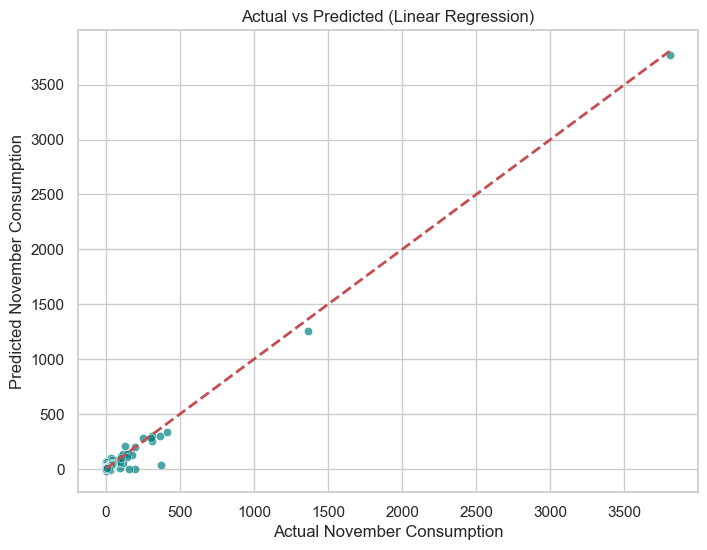

In [31]:
# 1. Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=final_preds, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual November Consumption')
plt.ylabel('Predicted November Consumption')
plt.title(f'Actual vs Predicted ({final_model_name})')
plt.show()


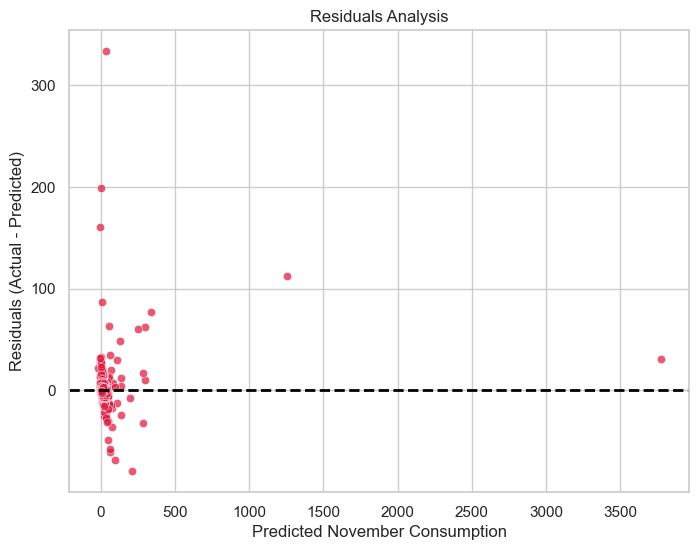

In [32]:
# 2. Residual Plot
residuals = y_test - final_preds
plt.figure(figsize=(8, 6))
sns.scatterplot(x=final_preds, y=residuals, alpha=0.7, color='crimson')
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted November Consumption')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Analysis')
plt.show()


Linear Regression coefficients instead:


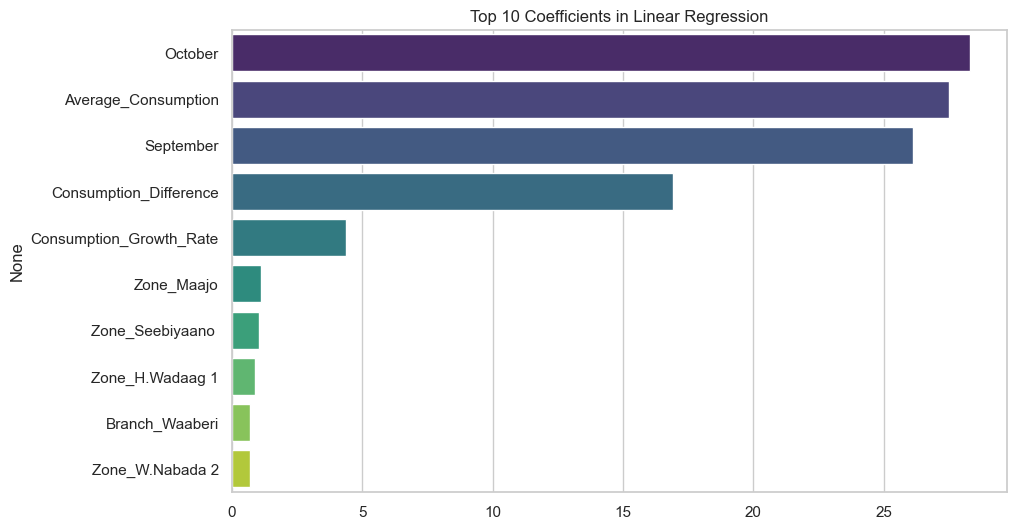

In [33]:
# 3. Feature Importance Plot (Top 10 features)
if hasattr(final_model, 'feature_importances_'):
    feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
    top_feats = feat_importances.nlargest(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_feats.values, y=top_feats.index, palette='viridis')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.title(f'Top 10 Feature Importances ({final_model_name})')
    plt.show()
else:
    print("Linear Regression coefficients instead:")
    coefs = pd.Series(models['Linear Regression'].coef_, index=X.columns).abs().sort_values(ascending=False)
    sns.barplot(x=coefs.head(10).values, y=coefs.head(10).index, palette='viridis')
    plt.title('Top 10 Coefficients in Linear Regression')
    plt.show()


## 18. Conclusion

### Business Interpretation:
- Predictive modelling of water consumption allows municipal utility companies to manage infrastructure allocation, detect local leakage patterns early, and optimize resource routing.
- Since past consumption (`September` and `October`) shows extremely high correlation with November usage, short-term consumption history is the strongest practical signal for forecasting.

### Model Performance Summary:
- All five requested regression models were trained with default parameters and evaluated using MAE, RMSE, R², and 5-fold cross-validation.
- The top three models from the combined test/CV ranking were selected for GridSearchCV tuning and compared against their untuned versions.
- In the verified run, **Linear Regression** was selected as the final model because it had the strongest balance of held-out test performance and cross-validation performance.

### Future Improvements:
- Incorporate weather and seasonal attributes such as temperature and rainfall.
- Include household size, customer type, or other demographic features for more detailed sub-population modelling.
- Re-run tuning when new months of consumption data become available, because the best model may change as the dataset grows.
